In [1]:
import os 
import pandas as pd
import re
from pathlib import Path
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

dirs = {
    "nemo_root": r"/Volumes/lab-windingm/data/instruments/behavioural_rigs/plugcamera",
    "main-nemo" :r"/Volumes/lab-windingm/home/shared/behavioural-rigs_data",
    "main-local": r"/Users/meryv/repos/behavioural-rigs",
    "weekly-sheets" : r"/Volumes/lab-windingm/home/shared/behavioural-rigs_data/weekly-sheets", 
    "final-sheets" : r"/Volumes/lab-windingm/home/shared/behavioural-rigs_data/final-weekly-sheets", 
    "backup": r"/Volumes/lab-windingm/home/shared/behavioural-rigs_data/25-online-sheets", 
    "mechano-screen": r"/Users/meryv/repos/behavioural-rigs/mechano-screen-sheets"
}

meta_cols = [
    'experimenter', 'collector', 'incubator', 'shelf', 'rack',
    'plugcamera', 'condition', 'location', 'staging_date',
    'amendments', 'comments', 'recording_time', 'staging_times', 'Pupae'
]

health_cols = [
    'condition',
    'mon_pm_mortality_n',
    'mon_removed_eggs_binary',
    'tues_am_mortality_n',
    'tues_am_removed_eggs_binary',
    'tues_pm_mortality_n',
    'tues_removed_pm_eggs_binary',
    'weds_am_mortality_n',
    'weds_am_removed_eggs_binary',
    'weds_pm_mortality_n',
    'weds_pm_removed_eggs_binary',
    'thurs_am_mortality_n',
    'thurs_am_removed_eggs_binary',
    'thurs_pm_mortality_n',
    'thurs_pm_removed_eggs_binary',
    'fri_am_mortality_n',
    'fri_am_removed_eggs_binary',
    'fri_pm_mortality_n',
    'fri_pm_removed_eggs_binary',
]

COLUMN_GROUPS = {
    "health": health_cols,
    "meta": meta_cols,
}

In [ ]:
import os 
import pandas as pd
import re
from pathlib import Path
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

dirs = {
    "nemo_root": r"/Volumes/lab-windingm/data/instruments/behavioural_rigs/plugcamera",
    "main-nemo" :r"/Volumes/lab-windingm/home/shared/behavioural-rigs_data",
    "main-local": r"/Users/meryv/repos/behavioural-rigs",
    "weekly-sheets" : r"/Volumes/lab-windingm/home/shared/behavioural-rigs_data/weekly-sheets", 
    "final-sheets" : r"/Volumes/lab-windingm/home/shared/behavioural-rigs_data/final-weekly-sheets", 
    "backup": r"/Volumes/lab-windingm/home/shared/behavioural-rigs_data/25-online-sheets", 
    "mechano-screen": r"/Users/meryv/repos/behavioural-rigs/mechano-screen-sheets"
}

meta_cols = [
    'experimenter', 'collector', 'incubator', 'shelf', 'rack',
    'plugcamera', 'condition', 'location', 'staging_date',
    'amendments', 'comments', 'recording_time', 'staging_times', 'Pupae'
]

health_cols = [
    'condition',
    'mon_pm_mortality_n',
    'mon_removed_eggs_binary',
    'tues_am_mortality_n',
    'tues_am_removed_eggs_binary',
    'tues_pm_mortality_n',
    'tues_removed_pm_eggs_binary',
    'weds_am_mortality_n',
    'weds_am_removed_eggs_binary',
    'weds_pm_mortality_n',
    'weds_pm_removed_eggs_binary',
    'thurs_am_mortality_n',
    'thurs_am_removed_eggs_binary',
    'thurs_pm_mortality_n',
    'thurs_pm_removed_eggs_binary',
    'fri_am_mortality_n',
    'fri_am_removed_eggs_binary',
    'fri_pm_mortality_n',
    'fri_pm_removed_eggs_binary',
]

COLUMN_GROUPS = {
    "health": health_cols,
    "meta": meta_cols,
}

In [2]:
mechano_lines = pd.read_csv("/Users/meryv/repos/behavioural-rigs/260126_mechano-lines.csv")

In [3]:
sensory_lines = pd.read_csv("/Users/meryv/repos/behavioural-rigs/2025-10-13_split_stock_update.csv")

In [ ]:
def normalize_list(lst):
    # key = normalized; value = set of original spellings seen
    m = {}
    for x in lst:
        if x is None:
            continue
        s = str(x).strip()
        if s == "":
            continue
        k = s.casefold()  # better than lower() for case-insensitive matching
        m.setdefault(k, set()).add(s)
    return m

mechano_lines.columns = mechano_lines.columns.str.strip()
mechano_list = mechano_lines["Stock"].dropna().unique().tolist() 

sensory_lines.columns = sensory_lines.columns.str.strip()
sensory_list = sensory_lines["Stock"].dropna().unique().tolist() 

mech_map = normalize_list(mechano_list)
sens_map = normalize_list(sensory_list)

mech_keys = set(mech_map)
sens_keys = set(sens_map)

shared_keys = mech_keys & sens_keys
mech_only_keys = mech_keys - sens_keys
sens_only_keys = sens_keys - mech_keys

canonical = {}
for k in shared_keys | mech_only_keys | sens_only_keys:
    if k in mech_map:
        canonical[k] = sorted(mech_map[k])[0]
    else:
        canonical[k] = sorted(sens_map[k])[0]

shared_names = [canonical[k] for k in shared_keys]
mech_only_names = [canonical[k] for k in mech_only_keys]
sens_only_names = [canonical[k] for k in sens_only_keys]


All sheets together

In [29]:
final_dir = Path(dirs["final-sheets"]) #should only have active sheets in here to ensure quick running

csv_files = sorted(final_dir.glob("*.csv"))

dfs = []
for f in csv_files:
    tmp = pd.read_csv(f)
    tmp.columns = tmp.columns.str.strip()   
    tmp["sheet_file"] = f.name             #keeping track of where each row came from
    tmp["sheet_name"] = f.stem              
    dfs.append(tmp)

latest_sheets = pd.concat(dfs, ignore_index=True)

latest_sheets.columns

Index(['Unnamed: 0.1', 'experimenter', 'collector', 'shelf', 'rack',
       'plugcamera', 'condition', 'location', 'staging_date', 'amendments',
       'comments', 'staging_times', 'pupae', 'mon_pm_mortality_n',
       'tues_am_mortality_n', 'tues_pm_mortality_n',
       'weds_am_mortality_number', 'weds_pm_mortality_number',
       'weds_pm_removed_eggs_binary', 'thurs_am_mortality_number',
       'thurs_am_removed_eggs_binary', 'thurs_pm_mortality_n',
       'thurs_pm_removed_eggs_binary', 'fri_am_mortality_n',
       'fri_am_removed_eggs_binary', 'fri_pm_mortality_n', 'sheet_file',
       'sheet_name', 'Pupae', 'og_vial_date', 'mon_pm_removed_eggs_binary',
       'tues_pm_removed_eggs_binary', 'weds_am_mortality_am',
       'weds_am_removed_eggs_binary', 'weds_pm_mortality_n',
       'thurs_am_mortality_n', 'thurs_am_removed_eggs',
       'fri_pm_removed_eggs binary', 'Unnamed: 0',
       'tues_am_removed_eggs_binary', 'time', 'incubator',
       'mon_removed_eggs_binary', 'tues_rem

In [ ]:
exp_stats = latest_sheets[["condition", "plugcamera", "time", "staging_date_clean_dt", "amendments", "comments", "Pupae", "week"]].copy()

exp_stats["Pupae"] = pd.to_numeric(exp_stats["Pupae"], errors="coerce")
exp_stats = exp_stats.dropna(subset=["Pupae"])

exp_stats["condition"].value_counts()

condition
SS01717      9
SS01645      6
control-1    6
T3A10        6
T2C9         6
            ..
603021       1
SS02149      1
T1A1         1
SS01724      1
SS01705      1
Name: count, Length: 102, dtype: int64

In [ ]:
mortality_cols = [c for c in latest_sheets.columns if c.endswith("_mortality_n")]

mort_long = (
    latest_sheets[["condition"] + mortality_cols]
      .melt(id_vars=["condition"], var_name="var", value_name="mortality_n")
)

# classify source (sensory vs mechano) from the column name
# e.g. "sensory_mortality_n" -> "sensory"
mort_long["assay"] = mort_long["var"].str.replace(r"_mortality_n$", "", regex=True).str.lower()

# keep only numeric mortality
mort_long["mortality_n"] = pd.to_numeric(mort_long["mortality_n"], errors="coerce")
mort_long = mort_long.dropna(subset=["mortality_n"])

summary = (
    mort_long
      .groupby(["assay", "condition"], dropna=False)
      .agg(
          n=("mortality_n", "size"),
          mean_mortality=("mortality_n", "mean"),
          sd_mortality=("mortality_n", "std"),
      )
      .reset_index()
      .sort_values(["assay", "condition"])
)

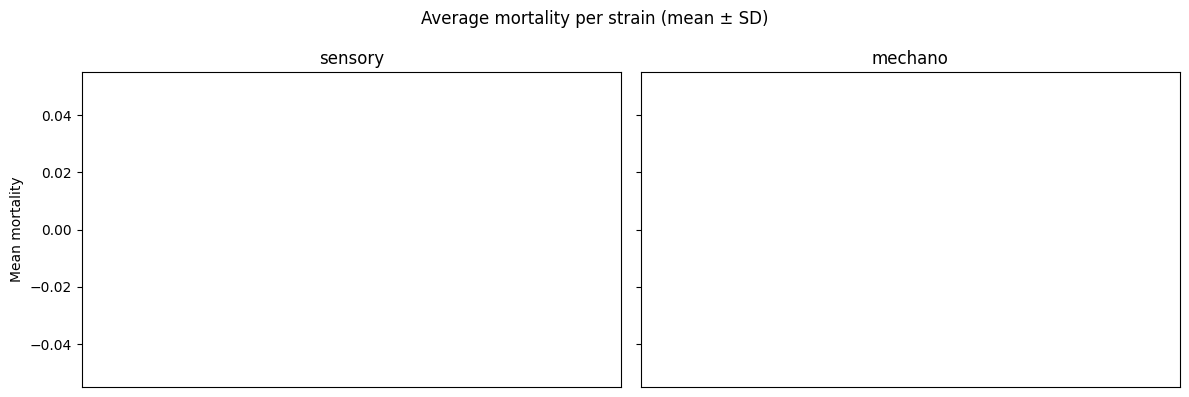

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, assay in zip(axes, ["sensory", "mechano"]):
    sub = summary[summary["assay"] == assay].sort_values("mean_mortality")
    x = np.arange(len(sub))

    ax.errorbar(
        x,
        sub["mean_mortality"],
        yerr=sub["sd_mortality"],
        fmt="o",
        capsize=4
    )

    ax.set_xticks(x)
    ax.set_xticklabels(sub["condition"], rotation=90)
    ax.set_title(assay)

    for i, n in enumerate(sub["n"]):
        ax.text(i,
                sub["mean_mortality"].iloc[i] + (sub["sd_mortality"].iloc[i] or 0) + 0.02,
                f"n={n}",
                ha="center",
                va="bottom",
                fontsize=8)

axes[0].set_ylabel("Mean mortality")
plt.suptitle("Average mortality per strain (mean ± SD)")
plt.tight_layout()
plt.show()


In [ ]:
DAY_ORDER  = ["mon", "tues", "weds", "thurs", "fri"]

mortality_cols = [c for c in latest_sheets.columns if c.endswith("_mortality_n")]

mort_long = (
    latest_sheets[["condition"] + mortality_cols]
      .melt(id_vars=["condition"], var_name="var", value_name="mortality_n")
)



,condition,var,mortality_n
0,control-1,mon_pm_mortality_n,n/k
1,control-2,mon_pm_mortality_n,n/k
2,SS01989,mon_pm_mortality_n,n/k
3,T13A06,mon_pm_mortality_n,n/k
4,T17A8,mon_pm_mortality_n,n/k
...,...,...,...
19822,SS01732,weds_am_mortality_n,NaN
19823,SPLIT-1,weds_am_mortality_n,NaN
19824,SS04068,weds_am_mortality_n,NaN
19825,603218,weds_am_mortality_n,NaN


Mechano sheets only

In [64]:
mechano_sheets = Path(dirs["mechano-screen"]) #should only have active sheets in here to ensure quick running

csv_files = sorted(mechano_sheets.glob("*.csv"))

dfs = []
for f in csv_files:
    tmp = pd.read_csv(f)
    tmp.columns = tmp.columns.str.strip()   
    tmp["sheet_file"] = f.name             #keeping track of where each row came from
    tmp["sheet_name"] = f.stem              
    dfs.append(tmp)

mechano_sheets = pd.concat(dfs, ignore_index=True)

In [67]:
DAY_ORDER  = ["mon", "tues", "weds", "thurs", "fri"]
TIME_ORDER = ["am", "pm"]
TIMEPOINT_ORDER = [f"{d}_{t}" for d in DAY_ORDER for t in TIME_ORDER]

mortality_cols = [c for c in all_sheets.columns if c.endswith("_mortality_n")]

mort_long = (
    all_sheets[["condition"] + mortality_cols]
      .melt(id_vars=["condition"], var_name="var", value_name="mortality_n")
)

parsed = mort_long["var"].str.extract(r"^(mon|tues|weds|thurs|fri)_(am|pm)_mortality_n$")
mort_long["day"] = parsed[0]
mort_long["ampm"] = parsed[1]
mort_long = mort_long.dropna(subset=["day", "ampm"])

mort_long["timepoint"] = mort_long["day"] + "_" + mort_long["ampm"]
mort_long["timepoint"] = pd.Categorical(mort_long["timepoint"], 
                                        categories=TIMEPOINT_ORDER, 
                                        ordered=True
                                        )

mort_long["mortality_n"] = pd.to_numeric(
    mort_long["mortality_n"], errors="coerce"
)


In [68]:
missing_summary = (
    mort_long
      .groupby("timepoint")
      .agg(
          n_total=("mortality_n", "size"),
          n_missing=("mortality_n", lambda x: x.isna().sum())
      )
      .reset_index()
)

missing_summary["missing_frac"] = (
    missing_summary["n_missing"] / missing_summary["n_total"]
)

missing_summary


/var/folders/vp/kct0bnpj5g9_h6x43mk9x6n00000gp/T/ipykernel_18773/3528994039.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("timepoint")


,timepoint,n_total,n_missing,missing_frac
0,mon_am,0,0,NaN
1,mon_pm,1819,1709,0.939527
2,tues_am,1819,1772,0.974162
3,tues_pm,1819,1702,0.935679
4,weds_am,1819,1774,0.975261
5,weds_pm,1819,1683,0.925234
6,thurs_am,1819,1693,0.930731
7,thurs_pm,1819,1663,0.914239
8,fri_am,1819,1688,0.927982
9,fri_pm,1819,1738,0.955470


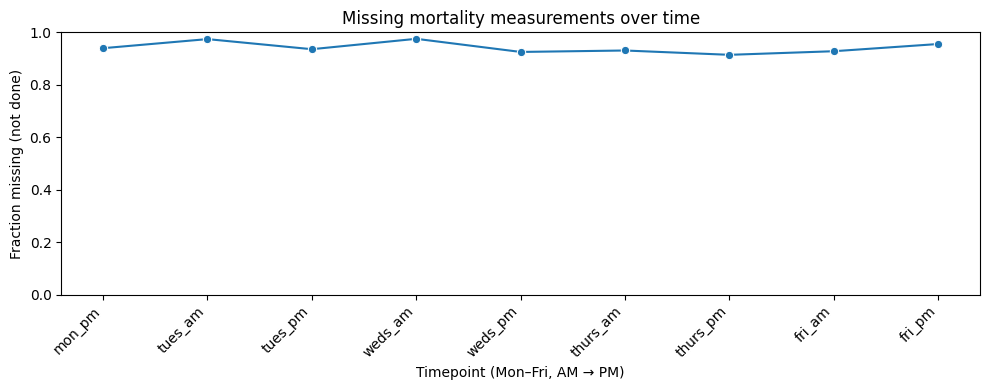

In [69]:
plt.figure(figsize=(10, 4))
sns.lineplot(
    data=missing_summary,
    x="timepoint",
    y="missing_frac",
    marker="o"
)

plt.title("Missing mortality measurements over time")
plt.xlabel("Timepoint (Mon–Fri, AM → PM)")
plt.ylabel("Fraction missing (not done)")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


/var/folders/vp/kct0bnpj5g9_h6x43mk9x6n00000gp/T/ipykernel_18773/2063242389.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["condition", "timepoint"], as_index=False)["mortality_n"]
/var/folders/vp/kct0bnpj5g9_h6x43mk9x6n00000gp/T/ipykernel_18773/2063242389.py:21: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


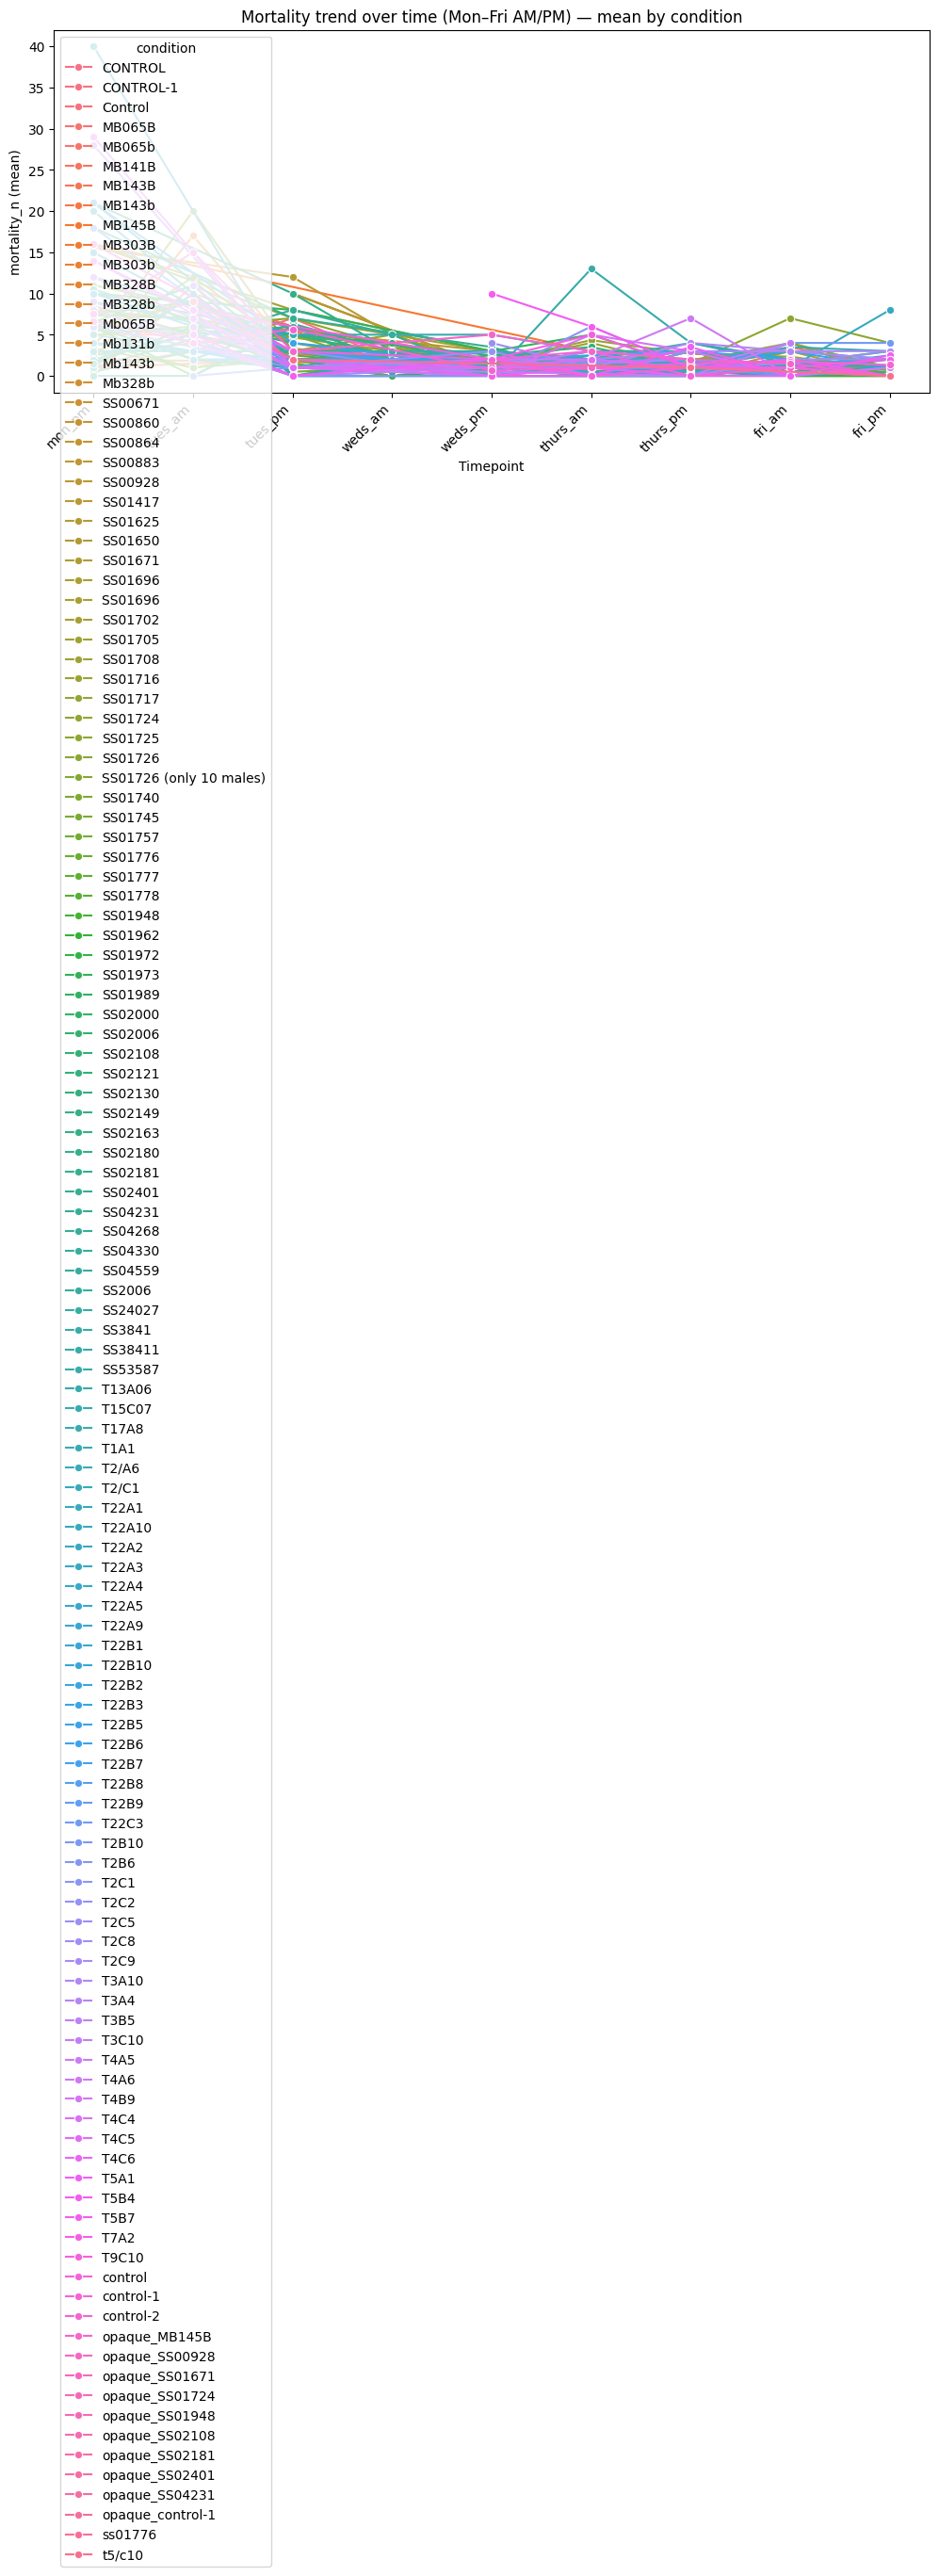

In [ ]:
agg_fn = "mean"   # change to "sum" if that's more appropriate for your data

mort_trend = (
    mort_long
      .groupby(["condition", "timepoint"], as_index=False)["mortality_n"]
      .agg(agg_fn)
)

plt.figure(figsize=(12, 5))
sns.lineplot(
    data=mort_trend,
    x="timepoint",
    y="mortality_n",
    hue="condition",
    marker="o"
)
plt.title(f"Mortality trend over time (Mon–Fri AM/PM) — {agg_fn} by condition")
plt.xlabel("Timepoint")
plt.ylabel(f"mortality_n ({agg_fn})")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

/var/folders/vp/kct0bnpj5g9_h6x43mk9x6n00000gp/T/ipykernel_18773/3671690942.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["condition", "timepoint"], as_index=False)["mortality_n"]
/var/folders/vp/kct0bnpj5g9_h6x43mk9x6n00000gp/T/ipykernel_18773/3671690942.py:46: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


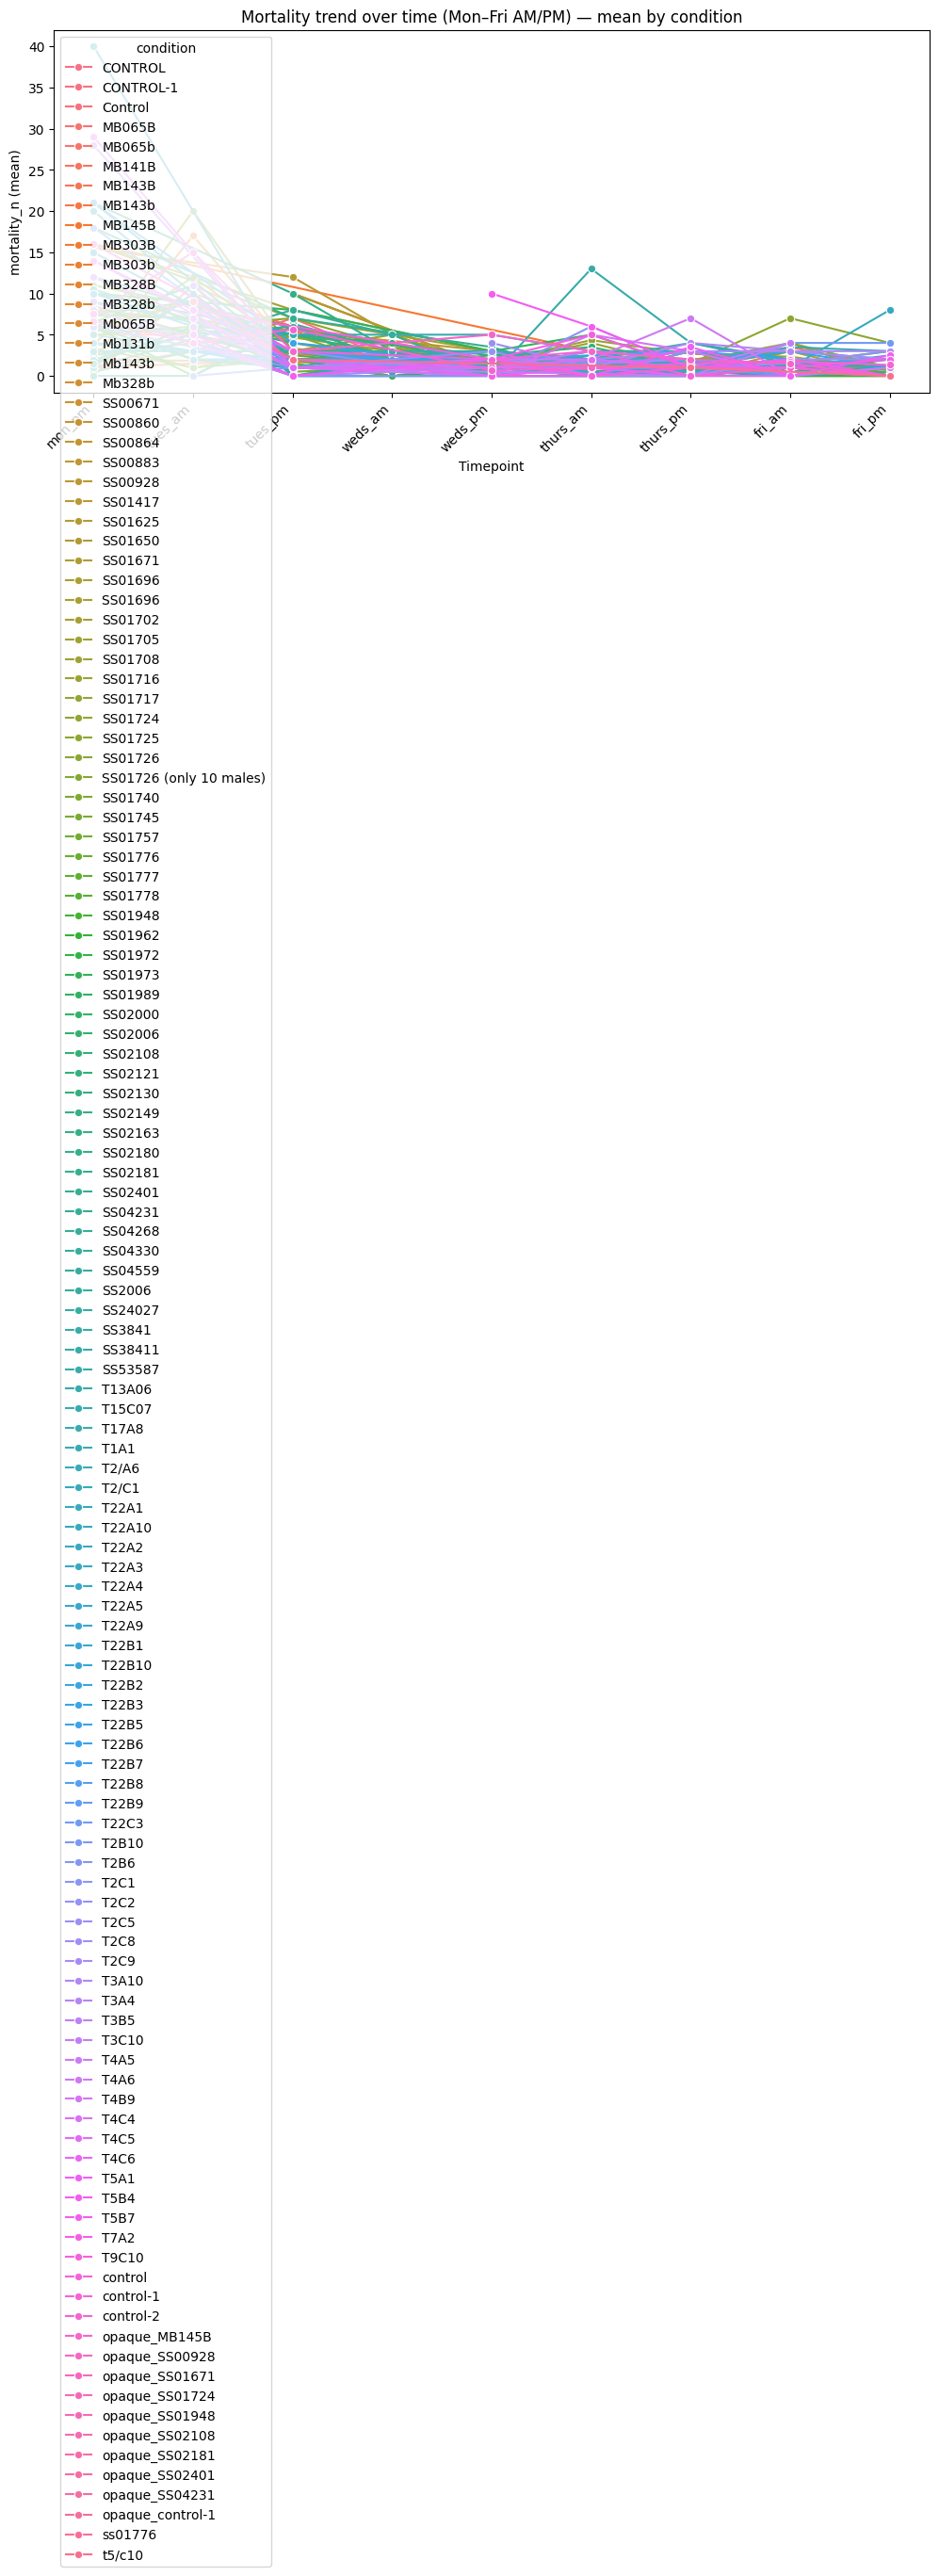

In [71]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

DAY_ORDER  = ["mon", "tues", "weds", "thurs", "fri"]
TIME_ORDER = ["am", "pm"]
TIMEPOINT_ORDER = [f"{d}_{t}" for d in DAY_ORDER for t in TIME_ORDER]

mortality_cols = [c for c in all_sheets.columns if c.endswith("_mortality_n")]

mort_long = (
    all_sheets[["condition"] + mortality_cols]
      .melt(id_vars=["condition"], var_name="var", value_name="mortality_n")
)

parsed = mort_long["var"].str.extract(r"^(mon|tues|weds|thurs|fri)_(am|pm)_mortality_n$")
mort_long["day"] = parsed[0]
mort_long["ampm"] = parsed[1]
mort_long = mort_long.dropna(subset=["day", "ampm"])

mort_long["timepoint"] = mort_long["day"] + "_" + mort_long["ampm"]
mort_long["timepoint"] = pd.Categorical(mort_long["timepoint"], categories=TIMEPOINT_ORDER, ordered=True)

# 🔧 critical fix: make mortality numeric
mort_long["mortality_n"] = pd.to_numeric(mort_long["mortality_n"], errors="coerce")

# mean trend per condition per timepoint
mort_trend = (
    mort_long
      .groupby(["condition", "timepoint"], as_index=False)["mortality_n"]
      .mean()
)

plt.figure(figsize=(12, 5))
sns.lineplot(
    data=mort_trend,
    x="timepoint",
    y="mortality_n",
    hue="condition",
    marker="o"
)
plt.title("Mortality trend over time (Mon–Fri AM/PM) — mean by condition")
plt.xlabel("Timepoint")
plt.ylabel("mortality_n (mean)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [ ]:
sheets_health = all_sheets[COLUMN_GROUPS["health"]]


In [27]:
week_1 = pd.read_csv("/Users/meryv/repos/behavioural-rigs/mechano-screen-sheets/2026-01-05_mechano-screen_week-1 - Sheet1.csv")
week_1.columns

Index(['experimenter', 'collector', 'incubator', 'shelf', 'rack', 'plugcamera',
       'condition', 'location', 'staging_date', 'amendments', 'comments',
       'recording_time', 'staging_times', 'Pupae', 'mon_pm_mortality_n',
       'mon_removed_eggs_binary', 'tues_am_mortality_n',
       'tues_am_removed_eggs_binary', 'tues_pm_mortality_n',
       'tues_removed_pm_eggs_binary', 'weds_am_mortality_n',
       'weds_am_removed_eggs_binary', 'weds_pm_mortality_n',
       'weds_pm_removed_eggs_binary', 'thurs_am_mortality_n',
       'thurs_am_removed_eggs_binary', 'thurs_pm_mortality_n',
       'thurs_pm_removed_eggs_binary', 'fri_am_mortality_n',
       'fri_am_removed_eggs_binary', 'fri_pm_mortality_n',
       'fri_pm_removed_eggs_binary'],
      dtype='object')

,experimenter,collector,incubator,shelf,rack,plugcamera,condition,location,staging_date,amendments,...,thurs_am_mortality_n,thurs_am_removed_eggs_binary,thurs_pm_mortality_n,thurs_pm_removed_eggs_binary,fri_am_mortality_n,fri_am_removed_eggs_binary,fri_pm_mortality_n,fri_pm_removed_eggs_binary,sheet_file,sheet_name
0,LK,HS,1,2,1,73,SS25755,NaN,13-14/01/2026,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-01-05_mechano-screen_week-1 - Sheet1.csv,2026-01-05_mechano-screen_week-1 - Sheet1
1,LK,HS,1,2,1,74,SS04330,NaN,13-14/01/2026,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-01-05_mechano-screen_week-1 - Sheet1.csv,2026-01-05_mechano-screen_week-1 - Sheet1
2,LK,HS,1,2,1,75,49826,NaN,13-14/01/2026,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-01-05_mechano-screen_week-1 - Sheet1.csv,2026-01-05_mechano-screen_week-1 - Sheet1
3,LK,HS,1,2,1,76,SS55086,NaN,13-14/01/2026,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-01-05_mechano-screen_week-1 - Sheet1.csv,2026-01-05_mechano-screen_week-1 - Sheet1
4,LK,HS,1,2,1,96,SS03767,NaN,13-14/01/2026,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-01-05_mechano-screen_week-1 - Sheet1.csv,2026-01-05_mechano-screen_week-1 - Sheet1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
379,LK,HS,incubator-1,shelf-2,rack-3,137,SS01732,NaN,23/01/2026,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-01-12_mechano-screen_week-2 - Sheet1.csv,2026-01-12_mechano-screen_week-2 - Sheet1
380,LK,HS,incubator-1,shelf-2,rack-3,138,SPLIT-1,NaN,23/01/2026,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,2026-01-12_mechano-screen_week-2 - Sheet1.csv,2026-01-12_mechano-screen_week-2 - Sheet1
381,LK,HS,incubator-1,shelf-2,rack-3,139,SS04068,NaN,23/01/2026,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,2026-01-12_mechano-screen_week-2 - Sheet1.csv,2026-01-12_mechano-screen_week-2 - Sheet1
382,LK,HS,incubator-1,shelf-2,rack-3,140,603218,NaN,23/01/2026,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-01-12_mechano-screen_week-2 - Sheet1.csv,2026-01-12_mechano-screen_week-2 - Sheet1
